In [2]:
import pandas as pd
import numpy as np

tennis_df = pd.read_csv("/Users/chiangethan/.cache/kagglehub/datasets/dissfya/atp-tennis-2000-2023daily-pull/versions/911/atp_tennis.csv")
#prepare for the dataset that contain proper point and odds value
df1 = tennis_df
print(df1.shape)

(66613, 17)


In [3]:
#create the dataset to calculate the past game winning percentage and record of players
winners = tennis_df.assign(
    Player = tennis_df["Winner"],
    Status = "win"
)[["Date", "Tournament", "Series", "Round", "Player", 
   "Status", "Court", "Surface", "Score"]]

losers = tennis_df.assign(
    Player = tennis_df.apply(lambda row: row["Player_1"] if row["Player_2"] == row["Winner"] else row["Player_2"], axis=1),
    Status = "loss"
)[["Date", "Tournament", "Series", "Round", "Player", 
   "Status", "Court", "Surface", "Score"]]

# Combine
individual_record_df = pd.concat([winners, losers], ignore_index=True)
individual_record_df = individual_record_df.sort_values("Date")
individual_record_df

,Date,Tournament,Series,Round,Player,Status,Court,Surface,Score
0,2000-01-03,Australian Hardcourt Championships,International,1st Round,Dosedel S.,win,Outdoor,Hard,6-4 6-2
66682,2000-01-03,Qatar Open,International,1st Round,Puerta M.,loss,Outdoor,Hard,5-7 2-6
66681,2000-01-03,Qatar Open,International,1st Round,Tarango J.,loss,Outdoor,Hard,7-6 7-6
66680,2000-01-03,Qatar Open,International,1st Round,Luxa P.,loss,Outdoor,Hard,6-4 0-6 2-6
66679,2000-01-03,Qatar Open,International,1st Round,Dupuis A.,loss,Outdoor,Hard,4-6 6-3 6-2
...,...,...,...,...,...,...,...,...,...
66610,2025-11-01,BNP Paribas Masters,Masters 1000,Semifinals,Auger-Aliassime F.,win,Indoor,Hard,7-6 6-4
133224,2025-11-01,BNP Paribas Masters,Masters 1000,Semifinals,Zverev A.,loss,Indoor,Hard,0-6 1-6
133223,2025-11-01,BNP Paribas Masters,Masters 1000,Semifinals,Bublik A.,loss,Indoor,Hard,7-6 6-4
66612,2025-11-02,BNP Paribas Masters,Masters 1000,The Final,Sinner J.,win,Indoor,Hard,6-4 7-6


In [111]:
def head_to_head(p1, p2, date):
    past_match = tennis_df[
        (((tennis_df["Player_1"] == p1) | (tennis_df["Player_1"] == p2)) & 
        ((tennis_df["Player_2"] == p1) | (tennis_df["Player_2"] == p2))) & 
        (tennis_df["Date"] < date)
    ].tail(1)
    if len(past_match) == 0:
        return None
    winner = past_match["Winner"].iloc[0]
    return winner
df1["Past_game_winner"] = df1.apply(lambda row: head_to_head(row["Player_1"], row["Player_2"], row["Date"]), axis = 1)
df1



,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score,Past_game_winner
0,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63,77,-1,-1,-1.00,-1.00,6-4 6-2,None
1,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56,5,-1,-1,-1.00,-1.00,3-6 3-6,None
2,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Escude N.,Baccanello P.,Escude N.,40,655,-1,-1,-1.00,-1.00,6-7 7-5 6-3,None
3,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Knippschild J.,Federer R.,Federer R.,87,65,-1,-1,-1.00,-1.00,1-6 4-6,None
4,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Fromberg R.,Woodbridge T.,Fromberg R.,81,198,-1,-1,-1.00,-1.00,7-6 5-7 6-4,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66608,BNP Paribas Masters,2025-10-31,Masters 1000,Indoor,Hard,Quarterfinals,3,Sinner J.,Shelton B.,Sinner J.,2,7,10500,3820,1.17,5.00,6-3 6-3,Sinner J.
66609,BNP Paribas Masters,2025-10-31,Masters 1000,Indoor,Hard,Quarterfinals,3,Medvedev D.,Zverev A.,Zverev A.,13,3,2810,6160,1.73,2.10,6-2 3-6 6-7,Medvedev D.
66610,BNP Paribas Masters,2025-11-01,Masters 1000,Indoor,Hard,Semifinals,3,Auger-Aliassime F.,Bublik A.,Auger-Aliassime F.,10,16,3195,2520,1.91,1.91,7-6 6-4,Auger-Aliassime F.
66611,BNP Paribas Masters,2025-11-01,Masters 1000,Indoor,Hard,Semifinals,3,Zverev A.,Sinner J.,Sinner J.,3,2,6160,10500,6.00,1.13,0-6 1-6,Sinner J.


In [114]:
#prepare for the dataset that contain proper point and odds value
df1 = df1[(df1["Pts_1"] >= 0) & (df1["Pts_2"] >= 0) & (df1["Odd_1"] >= 0) & (df1["Odd_2"] >= 0)]
df = df1.copy()

h2h_p1 = np.where(
    df["Past_game_winner"].isna(),                # never played before
    0,
    np.where(
        df["Past_game_winner"] == df["Player_1"], # last winner is Player_1
        1,
        -1                                        # otherwise Player_2
    )
)

df_p1 = pd.DataFrame({
    "Date": df["Date"],
    "Player": df["Player_1"],
    "rank_diff": df["Rank_1"] - df["Rank_2"],
    "pts_diff": df["Pts_1"] - df["Pts_2"],
    "odds_diff": df["Odd_1"] - df["Odd_2"],
    "series": df["Series"],
    "court": df["Court"],
    "surface": df["Surface"],
    "round": df["Round"],
    "head_to_head": h2h_p1,    
    "last_10_percent": np.nan,   
    "target": (df["Winner"] == df["Player_1"]).astype(int)
})

df_p2 = pd.DataFrame({
    "Date": df["Date"],
    "Player": df["Player_2"],
    "rank_diff": df["Rank_2"] - df["Rank_1"],
    "pts_diff": df["Pts_2"] - df["Pts_1"],
    "odds_diff": df["Odd_2"] - df["Odd_1"],
    "series": df["Series"],
    "court": df["Court"],
    "surface": df["Surface"],
    "round": df["Round"],
    "head_to_head": -h2h_p1,
    "last_10_percent": np.nan,
    "target": (df["Winner"] == df["Player_2"]).astype(int)
})

# --- Combine both perspectives ---
tennis_ml_df = pd.concat([df_p1, df_p2], ignore_index=True)
tennis_ml_df["abs"] = tennis_ml_df["rank_diff"].abs()
tennis_ml_df["abs2"] = tennis_ml_df["pts_diff"].abs()
tennis_ml_df = tennis_ml_df.sort_values(["Date", "abs", "abs2"])
tennis_ml_df.tail(10)

,Date,Player,rank_diff,pts_diff,odds_diff,series,court,surface,round,head_to_head,last_10_percent,target,abs,abs2
50787,2025-10-31,Medvedev D.,10,-3350,-0.37,Masters 1000,Indoor,Hard,Quarterfinals,1,NaN,0,10,3350
101578,2025-10-31,Zverev A.,-10,3350,0.37,Masters 1000,Indoor,Hard,Quarterfinals,-1,NaN,1,10,3350
50784,2025-10-31,Auger-Aliassime F.,-30,1912,-0.81,Masters 1000,Indoor,Hard,Quarterfinals,0,NaN,1,30,1912
101575,2025-10-31,Vacherot V.,30,-1912,0.81,Masters 1000,Indoor,Hard,Quarterfinals,0,NaN,0,30,1912
50789,2025-11-01,Zverev A.,1,-4340,4.87,Masters 1000,Indoor,Hard,Semifinals,-1,NaN,0,1,4340
101580,2025-11-01,Sinner J.,-1,4340,-4.87,Masters 1000,Indoor,Hard,Semifinals,1,NaN,1,1,4340
50788,2025-11-01,Auger-Aliassime F.,-6,675,0.00,Masters 1000,Indoor,Hard,Semifinals,1,NaN,1,6,675
101579,2025-11-01,Bublik A.,6,-675,0.00,Masters 1000,Indoor,Hard,Semifinals,-1,NaN,0,6,675
50790,2025-11-02,Sinner J.,-8,7305,-5.90,Masters 1000,Indoor,Hard,The Final,1,NaN,1,8,7305
101581,2025-11-02,Auger-Aliassime F.,8,-7305,5.90,Masters 1000,Indoor,Hard,The Final,-1,NaN,0,8,7305


In [115]:
def find_last_10_game(name, date):
    past_record = individual_record_df[(individual_record_df["Player"] == name) & (individual_record_df["Date"] < date)]
    if len(past_record) == 0:
        return 0.5
    if len(past_record) < 10:
        win_game = len(past_record[past_record["Status"] == "win"])
        number_of_game = len(past_record)
        adj_win_rate = (win_game + 5 * 0.5) / (number_of_game + 5)
        return adj_win_rate
    past_10 = past_record.tail(10)
    win_percentage = len(past_10[past_10["Status"] == "win"]) / 10
    return win_percentage

tennis_ml_df["last_10_percent"] = tennis_ml_df.apply(lambda row: find_last_10_game(row["Player"], row["Date"]), axis = 1)

In [134]:
mlearn_df = tennis_ml_df.copy()
mlearn_df = mlearn_df[["rank_diff", "pts_diff", "odds_diff", "series", "court", "surface", 
                       "round", "head_to_head", "last_10_percent", "target"]].reset_index(drop = True)

series_type = {'International': 0, 'International Gold': 1, 'Masters': 2, 'Grand Slam': 3, 
               'Masters Cup': 4, 'ATP250': 5, 'ATP500': 6, 'Masters 1000': 7}
court_type = {'Outdoor': 0, 'Indoor': 1}
surface_type = {'Clay': 0, 'Grass': 1, 'Hard': 2, 'Carpet': 3}
round_type = {'1st Round': 0, '2nd Round': 1, 'Quarterfinals': 2, 'Semifinals': 3, 
              'The Final': 4, '3rd Round': 5, '4th Round': 6, 'Round Robin': 7}

mlearn_df["series"] = mlearn_df["series"].map(series_type)
mlearn_df["court"] = mlearn_df["court"].map(court_type)
mlearn_df["surface"] = mlearn_df["surface"].map(surface_type)
mlearn_df["round"] = mlearn_df["round"].map(round_type)
mlearn_df

,rank_diff,pts_diff,odds_diff,series,court,surface,round,head_to_head,last_10_percent,target
0,-92,1044,-4.900,0,0,0,0,0,0.6,1
1,92,-1044,4.900,0,0,0,0,0,0.3,0
2,-127,484,1.000,0,0,1,0,-1,0.4,1
3,127,-484,-1.000,0,0,1,0,1,0.2,0
4,-373,576,-6.208,0,0,0,0,0,0.4,1
...,...,...,...,...,...,...,...,...,...,...
101577,-1,4340,-4.870,7,1,2,3,1,1.0,1
101578,-6,675,0.000,7,1,2,3,1,1.0,1
101579,6,-675,0.000,7,1,2,3,-1,0.7,0
101580,-8,7305,-5.900,7,1,2,4,1,1.0,1


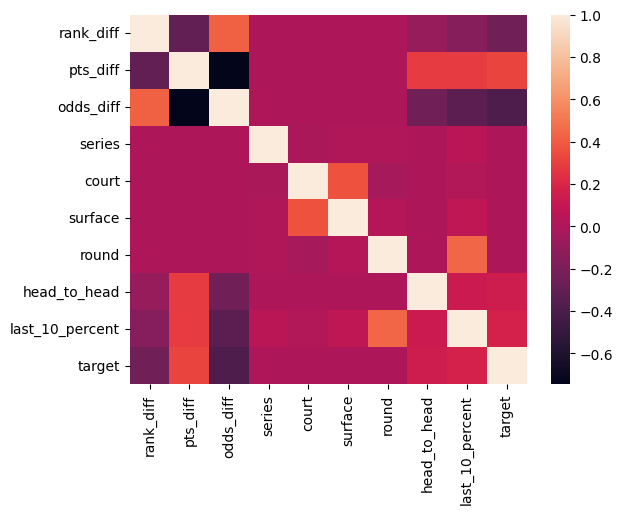

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(mlearn_df.corr())
plt.show()

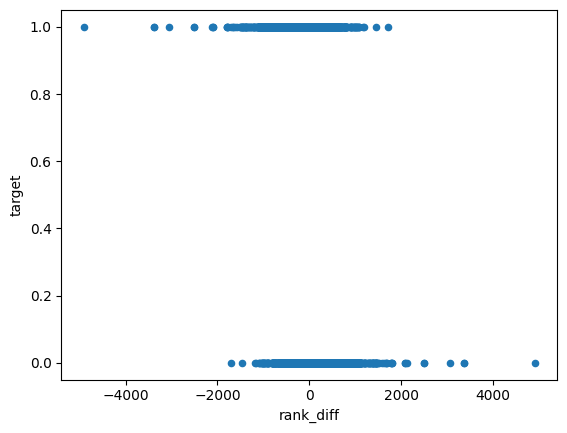

In [175]:
mlearn_df.plot.scatter(x = "rank_diff", y = "target")
plt.show()

Start training Logistic Model

In [135]:
from sklearn.model_selection import train_test_split

feature_cols = [
    "rank_diff",
    "pts_diff",
    "odds_diff",
    "series",
    "court",
    "surface",
    "round",
    "head_to_head",
    "last_10_percent"
]

X = mlearn_df[feature_cols]
y = mlearn_df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 67)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter = 1000))
])
model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
y_pred = model.predict(X_test)
print(model.score(X_test, y_test))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

NameError: name 'model' is not defined

In [158]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [160]:
rf_y_pred = rf.predict(X_test)
print(rf.score(X_test, y_test))
print(confusion_matrix(y_test, rf_y_pred))

0.698036127381011
[[7112 3024]
 [3111 7070]]


Save both logistics regression and Random Forest Classifier ML model 

In [165]:
import pickle

with open("model/logistic.pkl", "wb") as f:
    pickle.dump(model, f)

with open("model/random_forest.pkl", "wb") as f:
    pickle.dump(rf, f)